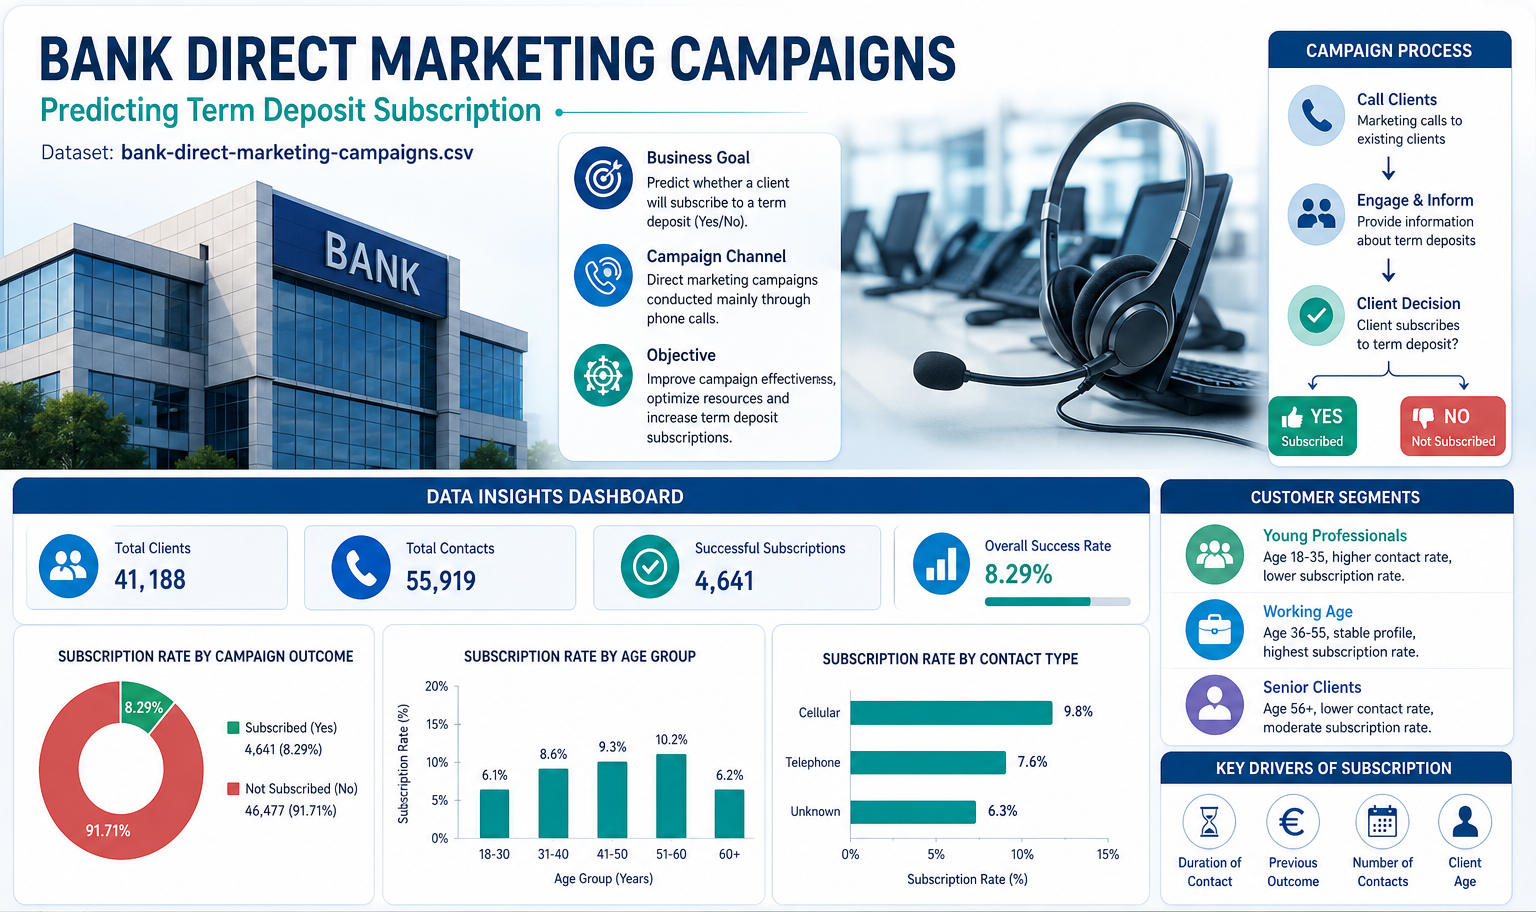

   # BANK DIRECT MARKETING CAMPAIGNS
Analysis and Prediction of Bank Direct Marketing Campaign Success.

  # INTRODUCTION
The banking industry uses direct marketing campaigns to communicate with customers and promote financial products. Understanding customer characteristics and campaign performance is important for improving marketing effectiveness.
This project analyzes bank direct marketing campaign data using tools Python, Pandas, Matplotlib, Seaborn, and Plotly. The analysis focuses on customer demographics, campaign details, subscription outcomes, and relationships between variables.
Bank Direct Marketing Campaigns dataset contains 41,188 customer records and 20 columns,
Analysis and Prediction of Bank Direct Marketing Campaign Success.






   # OBJECTIVE
The main objective of this project is to analyze bank direct marketing campaign data and identify factors associated with customer subscription. The project aims to support data-driven marketing decisions through data cleaning, exploratory data analysis, statistical summaries, and visualization.
The project will use data analytics techniques to understand customer characteristics, campaign performance, customer behavior, and economic factors associated with successful marketing outcomes.

    Specific Objectives :

1.	Understand the structure and characteristics of the bank's customer dataset. 
2.	Clean and preprocess the dataset for analysis. 
3.	Analyze customer demographics such as: 
*	Age 
*	Job 
*	Marital status 
*	Education 
4.	Analyze customer financial-related attributes such as: 
*	Housing loan 
*	Personal loan 
*	Default status 
5.	Analyze marketing campaign characteristics such as: 
*	Contact method 
*	Month 
*	Day of week 
*	Number of contacts 
*	Previous campaign outcome 
6.	Identify factors associated with successful term-deposit subscriptions. 
7.	Compare subscription rates across different customer groups. 
8.	Study relationships between numerical variables using correlation analysis. 
9.	Create meaningful visualizations to communicate important findings. 
10.	Generate business insights and recommendations for improving future bank marketing campaigns. 


# SCOPE
The scope of this project covers the complete data analytics lifecycle, beginning with data loading and ending with business recommendations.It covers customer demographic information, campaign contact details, economic indicators, and subscription outcomes available in the dataset.


   # METHODOLOGY
The project follows a structured data analytics workflow:
1.	Load the bank marketing dataset using Pandas.
2.	Inspect the dataset dimensions, columns, and data types.
3.	Check missing values, duplicate records, and unique values.
4.	Prepare the data for analysis.
5.	Perform univariate, bivariate, and multivariate analysis.
6.	Use groupby operations, pivot tables, descriptive statistics, and correlation analysis.
7.	Create meaningful visualizations using Matplotlib, Seaborn, and Plotly.
8.	Generate insights and provide recommendations.


   # DATASET OVERVIEW
The dataset contains 41,188 records and 20 columns. The target variable is y, which indicates whether a customer subscribed to the bank product. The dataset includes demographic information, loan-related details, campaign contacts, previous campaign outcomes, and economic indicators.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
df = pd.read_csv("bank-direct-marketing-campaigns.xls")
df.to_csv("bank-direct-marketing-campaigns.csv", index=False)
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


The dataset was loaded into Python using the Pandas library. The first five records were examined to understand the structure and format of the available variables.

In [7]:
df.shape

(41188, 20)

df.shape is used to find the number of rows and columns in your dataset.This means the project analyzes information from 41,188 customer/campaign records across 20 variables.

In [4]:
text_columns = df.select_dtypes(include='object').columns

for col in text_columns:
    df[col] = df[col].str.strip().str.lower()

print("Text columns standardized successfully.")

Text columns standardized successfully.


Column names were standardized by converting them to lowercase, removing extra spaces, and replacing dots/spaces with underscores. This makes the dataset easier to read and use consistently in Python analysis

In [5]:
df = df.rename(columns={
    'pdays': 'Days Since Previous Contact',
    'previous': 'Previous Contacts',
    'poutcome': 'Previous Campaign Result',
    'emp.var.rate': 'Employment Variation Rate',
    'cons.price.idx': 'Consumer Price Index',
    'cons.conf.idx': 'Consumer Confidence Index',
    'euribor3m': '3-Month Euribor Rate',
    'nr.employed': 'Number of Employees',
    'y': 'Term Deposit Subscription'
})

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,Days Since Previous Contact,Previous Contacts,Previous Campaign Result,Employment Variation Rate,Consumer Price Index,Consumer Confidence Index,3-Month Euribor Rate,Number of Employees,Term Deposit Subscription
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


Renaming technical column names into simple names makes the dataset, charts, and analysis easier for everyone to understand.

Examples:

* pdays          __    Days Since Contact
* previous       __    Previous Contacts
* poutcome       __    Previous Result
* emp.var.rate   __    Employment Rate
* cons.price.idx __    Consumer Price Index
* cons.conf.idx  __    Consumer Confidence
* euribor3m      __    3M Euribor Rate
* nr.employed    __    Employment Level
* y              __    Subscription

In [13]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'campaign',
       'Days Since Previous Contact', 'Previous Contacts',
       'Previous Campaign Result', 'Employment Variation Rate',
       'Consumer Price Index', 'Consumer Confidence Index',
       '3-Month Euribor Rate', 'Number of Employees',
       'Term Deposit Subscription'],
      dtype='object')

df.columns is used to display all column names in dataset.

In [14]:
df.dtypes

age                              int64
job                             object
marital                         object
education                       object
default                         object
housing                         object
loan                            object
contact                         object
month                           object
day_of_week                     object
campaign                         int64
Days Since Previous Contact      int64
Previous Contacts                int64
Previous Campaign Result        object
Employment Variation Rate      float64
Consumer Price Index           float64
Consumer Confidence Index      float64
3-Month Euribor Rate           float64
Number of Employees            float64
Term Deposit Subscription       object
dtype: object

 The dataset contains both numerical and categorical variables, making it suitable for customer and campaign analysis.

*  Numerical: Age, Campaign, Previous Contacts, economic indicators, etc.
*  Categorical: Job, Education, Contact, Previous Result, Subscription, etc.
*  Numerical columns can be used for statistical analysis and charts, while categorical columns help      analyze customer groups and campaign outcomes.

In [15]:
df.describe()

,age,campaign,Days Since Previous Contact,Previous Contacts,Employment Variation Rate,Consumer Price Index,Consumer Confidence Index,3-Month Euribor Rate,Number of Employees
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


df.describe() is used to display the statistical summary of numerical columns in dataset.
eg:Count,Mean,Standard deviation, Minimum ,Median ,Maximum .


In [16]:
df['Term Deposit Subscription'].value_counts()

Term Deposit Subscription
no     36548
yes     4640
Name: count, dtype: int64

df['Term Deposit Subscription'].value_counts() counts the number of customers in each subscription category. The overall subscription rate is approximately 11.27% (4,640 ÷ 41,188 × 100 = 11.27%). This shows that the target variable is imbalanced, as most customers did not subscribe to the term deposit.


   # DATA PREPROCESSING:
Data preprocessing is the process of cleaning and preparing the Bank Direct Marketing Campaigns dataset before performing analysis. It improves data quality and makes the dataset suitable for accurate analysis.Data preprocessing transforms raw data into clean, consistent, and analysis-ready data.
Main Pre-processing Steps
* Handling Missing Values
  Identify missing or null values and remove or replace them when necessary.
* Removing Duplicates
  Check for duplicate records and remove them to avoid repeated data.
* Correcting Data Types
  Ensure columns have the correct data type, such as numbers, text, or dates.
* Creating Derived Columns
  Create new useful columns from existing data, such as age groups or campaign-related categories.
* Filtering or Aggregating Data
  Filter the data based on specific requirements or aggregate it to identify useful patterns and trend

In [17]:
df.isnull().sum()

age                            0
job                            0
marital                        0
education                      0
default                        0
housing                        0
loan                           0
contact                        0
month                          0
day_of_week                    0
campaign                       0
Days Since Previous Contact    0
Previous Contacts              0
Previous Campaign Result       0
Employment Variation Rate      0
Consumer Price Index           0
Consumer Confidence Index      0
3-Month Euribor Rate           0
Number of Employees            0
Term Deposit Subscription      0
dtype: int64

df.isnull().sum() is used to find the number of missing (null) values in each column.

In [9]:
df['job'].value_counts()

job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

The job column shows the distribution of customers across different employment categories, with admin having the highest number of customers.The dataset contains 330 customers with an unknown job type, representing about 0.8% of all customers. These records are retained as a separate ‘Unknown’ category.

In [18]:
for col in df.select_dtypes(include='object'):
    print("\n", col)
    print(df[col].value_counts())



 job
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

 marital
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

 education
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

 default
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

 housing
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

 loan
loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64

 contact
con

*  select         _   dtypes(include='object') → selects categorical/text columns.
*  for col        _   checks each categorical column one by one.
*  value_counts()  _   counts how many times each category appears.
*  The categorical variables show different customer and campaign patterns. Most customers are married and have university-level education, while cellular is the main contact method. Some columns contain “unknown” values, which are retained as a separate category to avoid losing information.

In [19]:
df.duplicated().sum()




np.int64(1784)

The dataset contains 1,784 duplicate records. These duplicate rows can be removed during data preprocessing to avoid repeated records affecting the analysis.

In [20]:
df = df.drop_duplicates()

1,784 duplicate rows were identified and removed to prevent repeated records from affecting the analysis.

In [21]:
df.duplicated().sum()

np.int64(0)

The dataset was checked again, and no duplicate rows remain.

In [24]:
columns = [
    'age',
    'campaign',
    'Days Since Previous Contact',
    'Previous Contacts',
    'Employment Variation Rate',
    'Consumer Price Index',
    'Consumer Confidence Index',
    '3-Month Euribor Rate',
    'Number of Employees'
]

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, "→", len(outliers), "outliers")

age → 458 outliers
campaign → 2398 outliers
Days Since Previous Contact → 1514 outliers
Previous Contacts → 5546 outliers
Employment Variation Rate → 0 outliers
Consumer Price Index → 0 outliers
Consumer Confidence Index → 436 outliers
3-Month Euribor Rate → 0 outliers
Number of Employees → 0 outliers


    INSIGHT
* columns                       __     Selects the numerical variables that need outlier checking
*  Q1 = df[col].quantile(0.25)   __     It finds the 25% point (Q1) of the data — where 25% of the                                             values are below it and 75% are above it.
*  Q3 = df[col].quantile(0.75)   __     It finds the 75% point (Q3) of the data — where 75% of the                                             values are below it and 25% are above it.
*  IQR = Q3 - Q1                 __     Measures the spread of the middle 50% of the data.
*  lower = Q1 - 1.5 * IQR        __     values below this may be outliers.
*  upper = Q3 + 1.5 * IQR        __     values above this may be outliers
*  1.5 × IQR                     __       standard rule used in the IQR method.
* outliers = df[(df[col] < lower) | (df[col] > upper)] __  It finds and stores all rows whose values     are outside the lower and upper boundaries, so they can be identified as potential outliers.

1)  <   lower   __  values below the lower limit
2)  >   upper   __  values above the upper limit
3)  |   means   __    OR .it means either condition can be true.
*   print(col, "→", len(outliers), "outliers") __ Displays the number of potential outliers in each        column.


In [25]:

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    if len(outliers) > 0:
        print("\n", col)
        print(outliers[col].unique())


 age
[70 76 73 88 95 77 75 80 72 82 71 78 85 79 83 81 74 87 91 86 98 94 84 92
 89]

 campaign
[ 7  8  9 10 11 12 13 19 18 23 14 22 25 16 17 15 20 56 39 35 42 28 26 27
 32 21 24 29 31 30 41 37 40 33 34 43]

 Days Since Previous Contact
[ 6  4  3  5  1  0 10  7  8  9 11  2 12 13 14 15 16 21 17 18 22 25 26 19
 27 20]

 Previous Contacts
[1 2 3 4 5 6 7]

 Consumer Confidence Index
[-26.9]


      INSIGHT
*  for col in columns           __   Checks each numerical column one by one.
*  Q1 = df[col].quantile(0.25)  __  Finds the 25th percentile (Q1).
*  Q3 = df[col].quantile(0.75)  __  Q3 finds the third quartile (75th percentile), meaning 75% of the                                      values are at or below Q3, while 25% are above it.
*  IQR = Q3 - Q1                __  Calculates the Interquartile Range (IQR), which represents the                                         middle 50% of the data.
*   lower = Q1 - 1.5 * IQR      __  Calculates the lower boundary for identifying potential outliers.
*   upper = Q3 + 1.5 * IQR      __  Calculates the upper boundary for identifying potential outliers.
*   outliers = df[(df[col] < lower) | (df[col] > upper)]  __  Identifies values below the lower limit                                                          OR above the upper limit as potential outliers.
*  if len(outliers) > 0:        __ Checks whether the column contains at least one potential outlier.
*  print("\n", col)             __  Displays the name of the column containing potential outliers.
*  print(outliers[col].unique()) __Displays the unique values identified as potential outliers.

   # Exploratory Data Analysis
EDA is used to understand the dataset and find important patterns, trends, and relationships.
  Main points:
* Univariate analysis   : Analyze one variable at a time, such as age or job.
* Bivariate analysis    : Analyze the relationship between two variables, such as age and campaign      outcome.
* Multivariate analysis :Analyze three or more variables together to understand more complex           relationships.
* Groupby               : Group data by categories and calculate values such as count, average, or sum.
* Pivot table           : Summarize data in a simple table for comparison.
* Correlation analysis  :Identify the strength and direction of relationships between numerical  variables.

  #  Univariate Analysis
  1. Age Distribution 

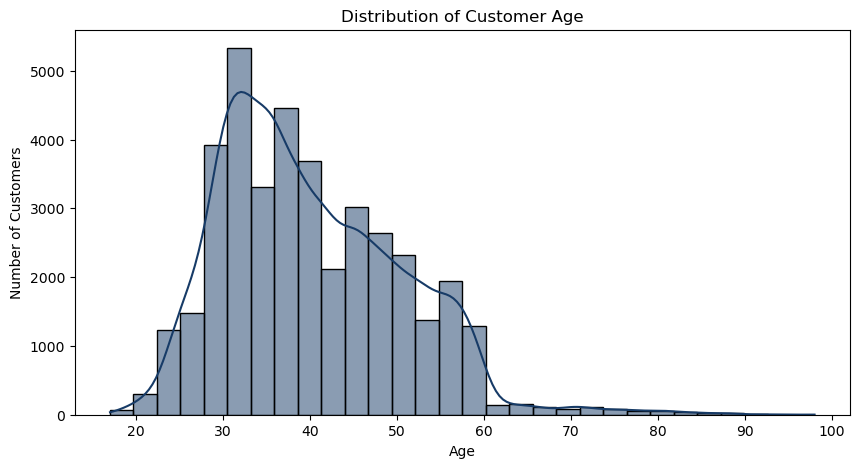

In [27]:

plt.figure(figsize=(10,5))

sns.histplot(
    df['age'],
    bins=30,
    kde=True,
    color='#173B67'
)

plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

     INSIGHT
* plt.figure(figsize=(10,5))   __    Creates a figure with a width of 10 and height of 5.
* sns.histplot(df['age'], bins=30, kde=True, color='#173B67')__Creates a histogram of customer ages.
* df['age']                    __   selects the age column.
* bins=30                      __   divides the ages into 30 groups.
* kde=True                     __   adds a smooth curve showing the overall age distribution.
* color='#173B67'              __   uses your navy-blue project color.
* plt.title("Distribution of Customer Age")  __  Adds the chart title.
* plt.xlabel("Age")           __    Labels the X-axis as Age.
* plt.ylabel("Number of Customers") __Labels the Y-axis as the number of customers.
* plt.show()                    __    Displays the chart.
The age distribution shows how customers are spread across different age groups. The histogram helps identify the most common customer ages and the overall shape of the age distribution.

 2. Job Analysis

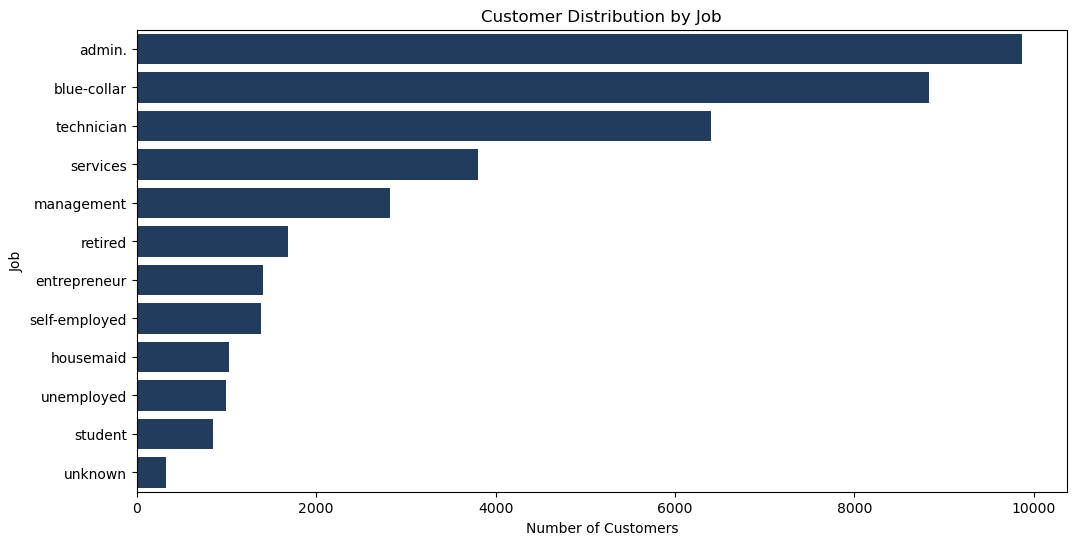

In [26]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y='job',
    order=df['job'].value_counts().index,
    color='#173B67'
)

plt.title("Customer Distribution by Job")
plt.xlabel("Number of Customers")
plt.ylabel("Job")

plt.show()


INSIGHT
* plt.figure(figsize=(12,6))  __  Creates a chart with a suitable size for displaying multiple job categories.
* sns.countplot(...) __ Creates a bar chart showing the number of customers in each job category.
* data=df            __ Tells Seaborn to use your dataset df.
* y='job'            __ Places the Job categories on the Y-axis.
* order=df['job'].value_counts().index __Sorts the job categories from highest number of customers to    lowest.
* color='#173B67'    __ Uses your project’s navy-blue color.
* plt.xlabel("Number of Customers") __ Shows the number of customers on the X-axis.
* plt.ylabel("Job")  __ Shows the job categories on the Y-axis.
* plt.show()         __ Displays the chart.


* The job distribution shows the number of customers in each occupation. The chart helps identify the most common and least common job categories among the customers, which can support customer segmentation for marketing campaigns.


3. Marital Status

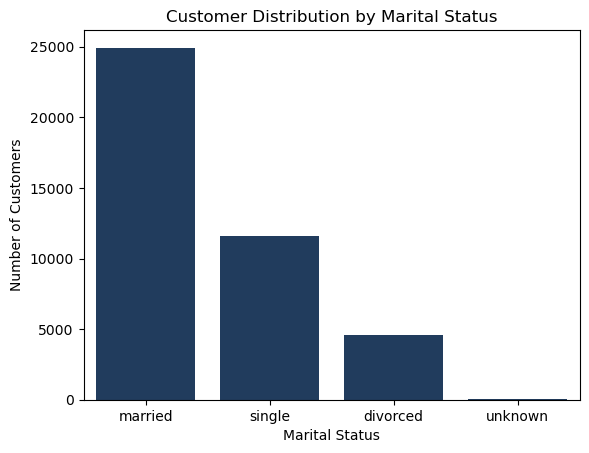

In [11]:
sns.countplot(
    data=df,
    x='marital',
    color='#173B67'
)

plt.title("Customer Distribution by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Number of Customers")

plt.show()

     INSIGHT
* sns.countplot(...)             __ Creates a bar chart showing the number of customers in each category.
* data=df                        __ Uses your dataset df.
* x='marital'                    __ Places the marital-status categories on the X-axis.
* color='#173B67'                __ Uses your navy-blue project color.
* plt.title(...)                 __ Adds the chart title.
* plt.xlabel("Marital Status")   __Labels the X-axis.
* plt.ylabel("Number of Customers")__Labels the Y-axis with the customer count.
* plt.show()                     __Displays the chart.


* The marital status distribution shows the number of customers in each marital category. The chart helps identify the dominant marital-status group and understand the overall customer profile for marketing analysis.

4. Education

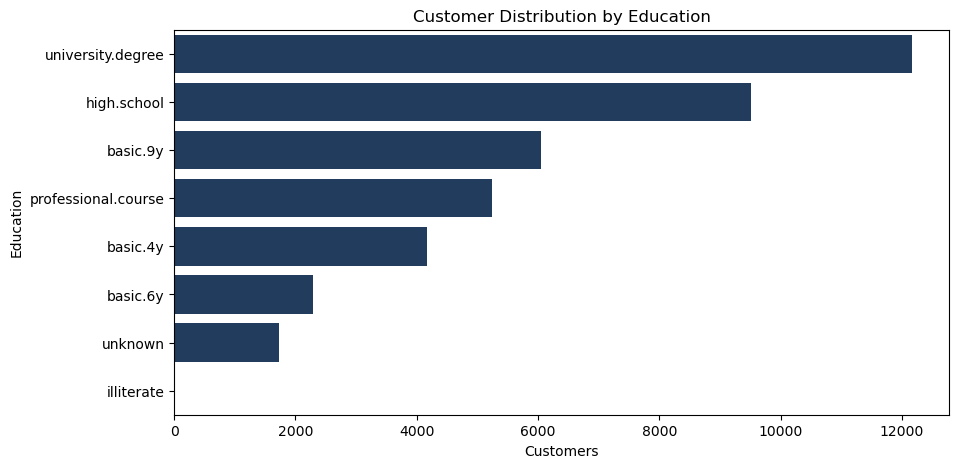

In [12]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y='education',
    order=df['education'].value_counts().index,
    color='#173B67'
)

plt.title("Customer Distribution by Education")
plt.xlabel("Customers")
plt.ylabel("Education")

plt.show()


    INSIGHT
* Y-axis         __   Education categories
*  X-axis         __   Number of customers
*  countplot      __   counts how many customers belong to each education category.
*  order=df['education'].value_counts().index  __ displays the education categories from highest number of customers to lowest.
*  color='#173B67' __  Uses your Navy Blue color.     
*  The chart shows the distribution of customers across different education levels. The education category with the longest bar represents the largest customer group, while shorter bars represent smaller customer groups. This helps identify the dominant education background among the customers targeted by the bank's marketing campaigns.

5. Target Variable Analysis

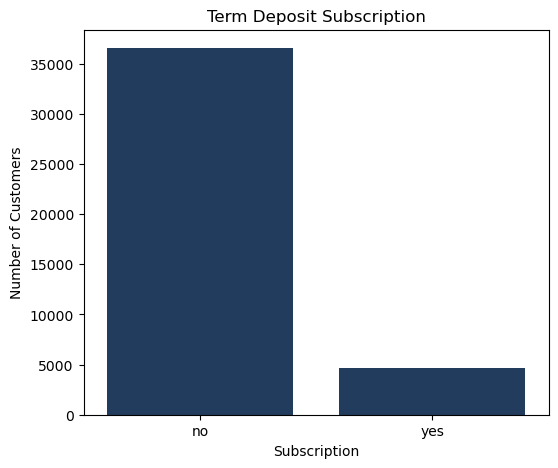

In [7]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='Term Deposit Subscription',
    color='#173B67'
)

plt.title("Term Deposit Subscription")
plt.xlabel("Subscription")
plt.ylabel("Number of Customers")

plt.show()

    INSIGHT
* y = yes    __  Customer subscribed to the term deposit
* y = no     __  Customer did not subscribe
* X-axis     __  Subscription status
* Y-axis     __  Number of customers
* color='#173B67'__  Uses your Navy Blue color.
* The majority of customers did not subscribe to the term deposit, while only a smaller proportion subscribed. This indicates that the campaign had a relatively low subscription rate and highlights the need to identify customer and campaign factors associated with successful subscriptions.


# Bivariate Analysis ( compare two variables )
   1. Job vs Subscription 

In [6]:
job_subscription = df.groupby('job')['Term Deposit Subscription'].apply(
    lambda x: (x == 'yes').mean() * 100
).sort_values(ascending=False)

     INSIGHT
*  df.groupby('job')        __    Groups customers according to their job category.
*  ['y']                    __    each customer subscribed (yes) or not (no).
* (x == 'yes').mean() * 100 __    Calculate subscription rate
 This analysis calculates the percentage of customers who subscribed to the term deposit for each job category and sorts the job categories from highest to lowest subscription rate.

    job_subscription (Visualization)


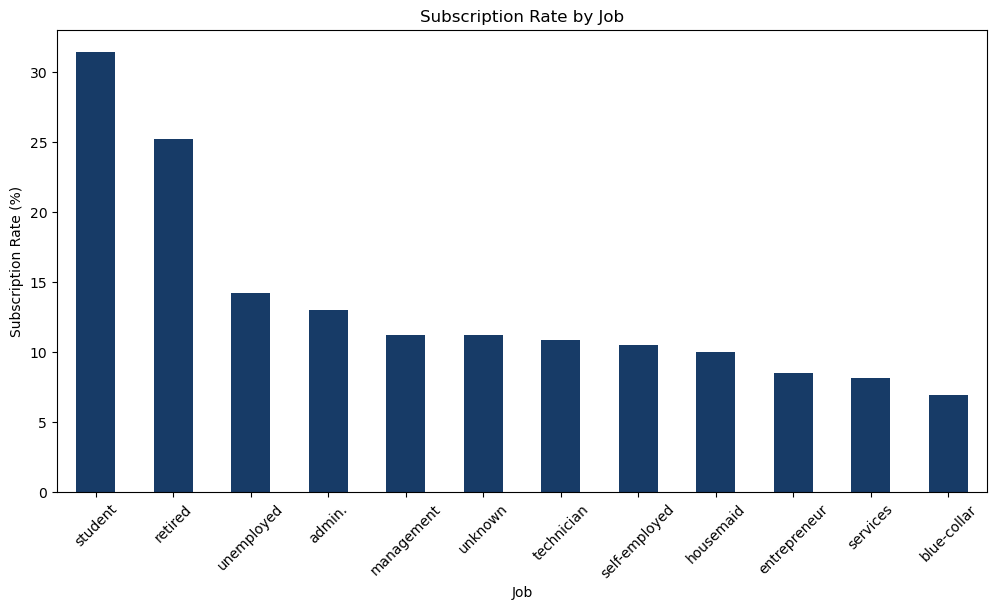

In [16]:
job_subscription.plot(
    kind='bar',
    figsize=(12,6),
    color='#173B67'
)

plt.title("Subscription Rate by Job")
plt.xlabel("Job")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=45)

plt.show()


     INSIGHT
* job_subscription.plot(
    kind='bar',             __  Creates a bar chart using your job_subscription values.
* figsize=(12,6)            __  Makes the chart wider and easier to read.
* color='#173B67'           __  Uses your Navy Blue color.
* plt.title("Subscription Rate by Job")__ the chart compares job categories and subscription rates.
* plt.xlabel("Job")         __  The X-axis contains the different job categories.
* plt.ylabel("Subscription Rate (%)")  __  Y-axis shows the percentage of customers who subscribed.
* plt.xticks(rotation=45)   __   Rotates the job labels by 45° so longer names are easier to read.
. Highest bar _  job category with the highest subscription rate.
.Lowest bar   _  job category with the lowest subscription rate.
.Longer bars  _  relatively higher subscription rates.
.Shorter bars _  relatively lower subscription rates
Subscription rates vary across job categories. Some job groups show higher subscription rates, while others show lower rates, indicating that job type may be associated with customers' response to the marketing campaign.

2. Education vs Subscription

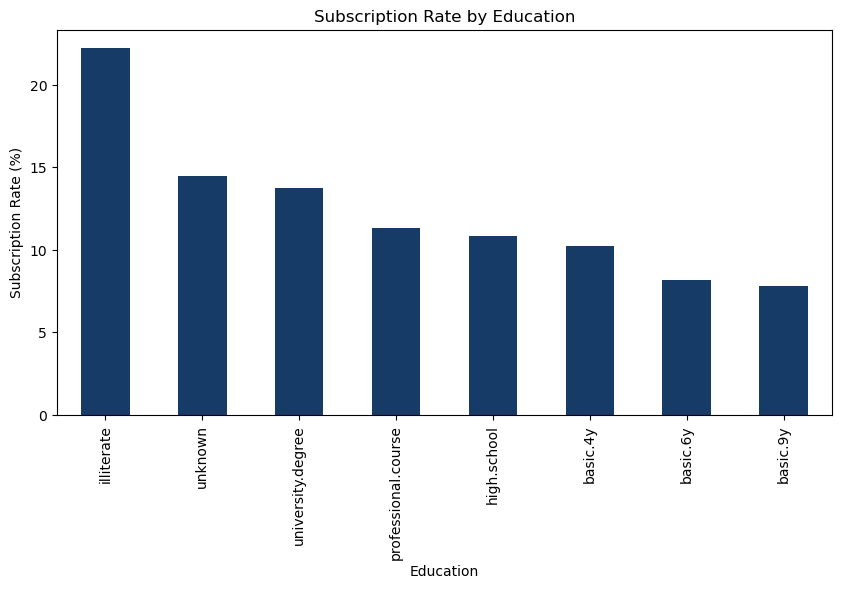

In [8]:
education_rate = df.groupby('education')['Term Deposit Subscription'].apply(
    lambda x: (x == 'yes').mean() * 100
).sort_values(ascending=False)

education_rate.plot(
    kind='bar',
    figsize=(10,5),
    color='#173B67'
)

plt.title("Subscription Rate by Education")
plt.xlabel("Education")
plt.ylabel("Subscription Rate (%)")

plt.show()


      INSIGHT
* df.groupby('education')[Term Deposit Subscription ]   __ it compares customers based on their education level.
* (x == 'yes').mean() * 100      __  Calculates the percentage of customers who subscribed within each                                      education category.
* .sort_values(ascending=False)  __ Places education categories from highest subscription rate to                                           lowest.
* education_rate.plot(kind='bar') __ Each bar represents the subscription rate for an education                                             category.
* Subscription rates vary across education levels. Some education groups have higher subscription rates, while others have lower rates. This indicates that education level may be associated with customers' response to the bank's marketing campaign and can help identify customer segments with different subscription patterns.

   3. Contact Method vs Subscription

contact
cellular     14.737607
telephone     5.231321
Name: Term Deposit Subscription, dtype: float64


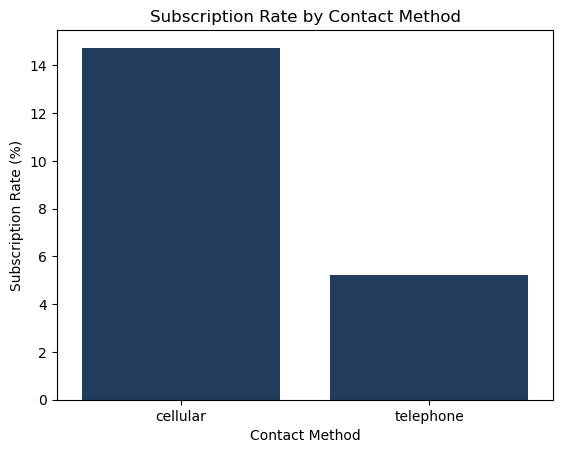

In [9]:
contact_rate = df.groupby('contact')['Term Deposit Subscription'].apply(
    lambda x: (x == 'yes').mean() * 100
)

print(contact_rate)

sns.barplot(
    x=contact_rate.index,
    y=contact_rate.values,
    color='#173B67'
)

plt.title("Subscription Rate by Contact Method")
plt.xlabel("Contact Method")
plt.ylabel("Subscription Rate (%)")

plt.show()



      INSIGHT
* df.groupby('contact')['Term Deposit Subscription']   __  Customers are grouped according to how they were contacted.Group customers according to their contact method and then examine their subscription result (y).
* (x == 'yes').mean() * 100    __   Calculates the percentage of customers who subscribed for each contact method.
* A higher bar                 __    higher subscription rate.
* A lower bar                  __    lower subscription rate.
* Subscription rates differ by contact method. This indicates that the method used to contact customers may be associated with their response to the marketing campaign. Comparing these rates can help the bank understand which contact channels have different levels of customer response.

   # GroupBy Analysis 

 1.  Average customer age by occupation

In [31]:
df.groupby('job')['age'].mean().sort_values(ascending=False)

job
retired          62.039216
housemaid        45.535019
unknown          45.507692
management       42.397163
entrepreneur     41.648399
self-employed    39.999278
unemployed       39.812500
blue-collar      39.574986
technician       38.574016
admin.           38.343361
services         37.991055
student          25.907277
Name: age, dtype: float64

     INSIGHT
* groupby('job')     __  groups customers by their job category.
* ['age']            __ selects the age column.
* .mean()            __ calculates the average age for each job category.
* .sort_values(ascending=False) __ sorts jobs from highest average age to lowest average age.
* The average age varies across job categories. Some job groups have a higher average customer age, while others have a lower average age. This helps the bank understand the age profile of customers within different occupational groups.

 2. Average Age by Marital Status

In [32]:
df.groupby('marital')['age'].mean()

marital
divorced    44.912312
married     42.395995
single      33.220697
unknown     40.417722
Name: age, dtype: float64

     INSIGHT
This analysis calculates the average age of customers for each marital status category. It helps us compare the average age of married, single, and divorced customers.
* groupby('marital')     __  groups customers by marital status.
* ['age']                __ selects the age column.
* .mean()                __ calculates the average age for each marital-status group.
  

3. Average Number of Campaign Contacts for each Contact Method

In [33]:
df.groupby('contact')['campaign'].mean()

contact
cellular     2.462733
telephone    2.880049
Name: campaign, dtype: float64

    INSIGHT
Customers contacted by telephone received an average of 2.88 campaign contacts, compared with 2.46 contacts for cellular customers. This indicates that telephone contacts had a slightly higher average campaign contact frequency than cellular contacts.
* groupby('contact')    __  groups customers by contact method.
* ['campaign']          __ selects the number of contacts made during the current campaign.
* .mean()               __ calculates the average number of campaign contacts for each contact method.

   # Pivot Tables 

    1 Average Age by Job and Term Deposit Subscription

In [31]:
pivot = pd.pivot_table(
    df,
    values='age',
    index='job',
    columns='Term Deposit Subscription',
    aggfunc='mean'
)

pivot

Term Deposit Subscription,no,yes
job,,
admin.,38.394120,38.018727
blue-collar,39.600463,39.244866
entrepreneur,41.637072,41.768595
housemaid,44.716920,52.650943
management,42.342021,42.819018
retired,59.933706,68.155452
self-employed,40.239289,38.006711
services,38.169876,36.059006
student,26.437177,24.771218


    INSIGHT
* df	                                __  Your Bank Direct Marketing dataset.
* values='age'	                        __ We want to calculate the average of age.
* index='job'	                        __ Job categories appear as the rows.
* columns='Term Deposit Subscription'	__ Subscription status appears as the columns.
* aggfunc='mean'	                    __ Calculate the average (mean) age.
* This table compares the average customer age by job and subscription status.The pivot table compares the average age of customers who subscribed and did not subscribe across different job categories. This helps identify differences in the age profile of subscription outcomes within each job group.

    2 Average Campaign Contacts by Month and Term Deposit Subscription

In [32]:
pd.pivot_table(
    df,
    values='campaign',
    index='month',
    columns='Term Deposit Subscription',
    aggfunc='mean'
)

Term Deposit Subscription,no,yes
month,,
apr,2.023964,1.781955
aug,2.832281,2.238095
dec,2.279570,2.034091
jul,3.345449,2.618605
jun,3.198678,2.214801
mar,2.545802,1.914179
may,2.498592,2.130385
nov,1.975422,1.649635
oct,1.597468,1.500000


    INSIGHT
* Pivot Table showing the average number of campaign contacts for each month, separated by subscription status.
* values='campaign'                  __ calculates the average number of campaign contacts
* index='month'                      __rows represent each month
* columns='Term Deposit Subscription'__ separates customers into yes/no
* aggfunc='mean'                     __ calculates the average
* The pivot table compares the average number of campaign contacts across different months for customers who subscribed and those who did not. It helps identify monthly differences in campaign contact frequency and customer response.



  #  Correlation Analysis (numerical variables)

In [27]:
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

corr


,age,campaign,Days Since Previous Contact,Previous Contacts,Employment Variation Rate,Consumer Price Index,Consumer Confidence Index,3-Month Euribor Rate,Number of Employees
age,1.000000,0.004594,-0.034369,0.024365,-0.000371,0.000857,0.129372,0.010767,-0.017725
campaign,0.004594,1.000000,0.052584,-0.079141,0.150754,0.127836,-0.013733,0.135133,0.144095
Days Since Previous Contact,-0.034369,0.052584,1.000000,-0.587514,0.271004,0.078889,-0.091342,0.296899,0.372605
Previous Contacts,0.024365,-0.079141,-0.587514,1.000000,-0.420489,-0.203130,-0.050936,-0.454494,-0.501333
Employment Variation Rate,-0.000371,0.150754,0.271004,-0.420489,1.000000,0.775334,0.196041,0.972245,0.906970
Consumer Price Index,0.000857,0.127836,0.078889,-0.203130,0.775334,1.000000,0.058986,0.688230,0.522034
Consumer Confidence Index,0.129372,-0.013733,-0.091342,-0.050936,0.196041,0.058986,1.000000,0.277686,0.100513
3-Month Euribor Rate,0.010767,0.135133,0.296899,-0.454494,0.972245,0.688230,0.277686,1.000000,0.945154
Number of Employees,-0.017725,0.144095,0.372605,-0.501333,0.906970,0.522034,0.100513,0.945154,1.000000


     INSIGHT
* numeric_df =            __  Creates a new variable
* df.select_dtypes()      __Pandas to select columns based on their data type.
Your dataset contains different types of columns:
Numerical                 __  age, campaign, pdays, previous
Text                      __ job, education, marital, month
* include=np.number       __ Select only numerical columns.
* numeric_df              __ contains only numerical columns.
* .corr()                 __  calculates the correlation values.
* corr                    __ stores the resulting correlation matrix.
* Employment Variation Rate and 3-Month Euribor Rate show a very strong positive correlation (0.972), indicating they move closely together.
* 3-Month Euribor Rate and Number of Employees also have a very strong positive correlation (0.945).
* Employment Variation Rate and Number of Employees have a strong positive correlation (0.907).
* Employment Variation Rate and Consumer Price Index show a strong positive correlation (0.775).
* Previous Contacts and Days Since Previous Contact have a moderate negative correlation (-0.588).
* Age has very weak correlations with most variables, suggesting little linear relationship with these numerical campaign and economic factors.
* Campaign has generally weak correlations with other variables, with its highest correlation being with Employment Variation Rate (0.151).
* The strongest relationships are among the economic indicators, especially Employment Variation Rate, Euribor Rate, and Number of Employees. In contrast, age and campaign contacts show relatively weak linear relationships with most numerical variables.


   ## Calculates the correlation between the numerical columns.

    Statistical Analysis

In [29]:
df['age'].mean()
df['age'].median()
df['age'].std()
df['age'].min()
df['age'].max()
df['age'].describe()


count    41188.00000
mean        40.02406
std         10.42125
min         17.00000
25%         32.00000
50%         38.00000
75%         47.00000
max         98.00000
Name: age, dtype: float64

    INSIGHT
* Mean                 __       (40)average age of customers.
* Median               __      (38_50%) middle age when ages are arranged in order.
* Standard deviation   __       (10.42) shows how much ages vary around the average.
* Minimum              __       (17) youngest age in the dataset.
* Maximum              __      (98) oldest age in the dataset.

 

   # Multivariate Analysis (combine several variables)

    Campaign Contacts by Education and Term Deposit Subscription

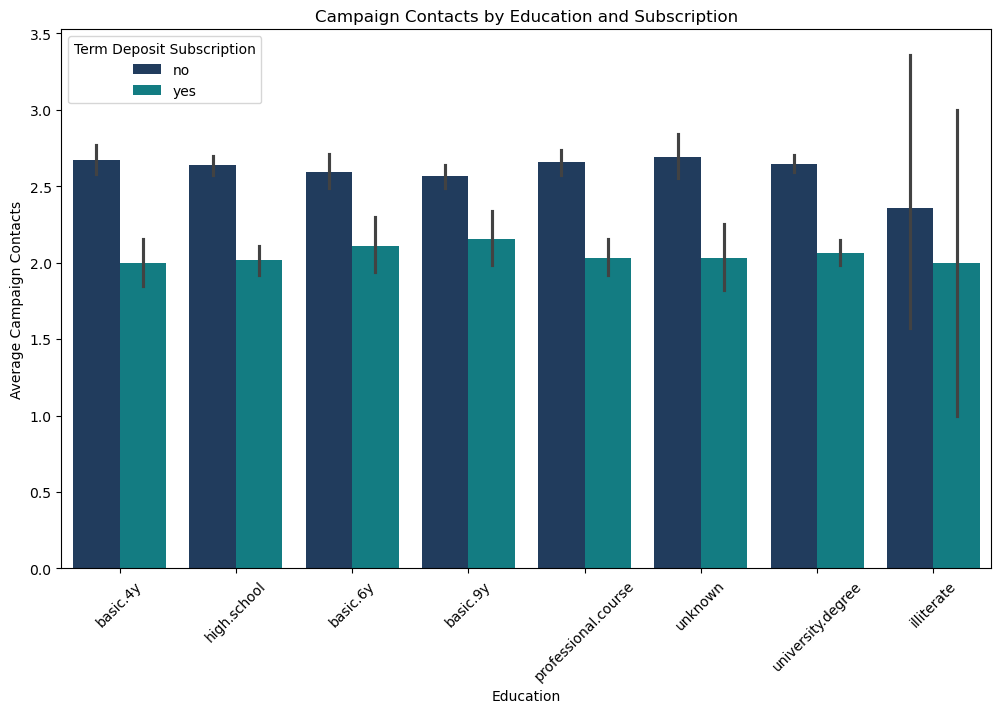

In [10]:
plt.figure(figsize=(12,7))

sns.barplot(
    data=df,
    x='education',
    y='campaign',
    hue='Term Deposit Subscription',
    palette=['#173B67', '#008C95']
)

plt.title("Campaign Contacts by Education and Subscription")
plt.xlabel("Education")
plt.ylabel("Average Campaign Contacts")

plt.xticks(rotation=45)

plt.show()

     INSIGHT
* plt.figure(figsize=(12,7)) __ Creates the chart area ( width 12 and height 7 ).
* sns.barplot(  __ Creates a bar chart using Seaborn.
* data=df   __  Bank Direct Marketing dataset stored in df.  
* x='education'  __ The X-axis contains different education categories.
* y='campaign' __ The Y-axis represents the campaign variable.
* hue='Term Deposit Subscription' __ This separates each education category into two groups:
  yes __ Customer subscribed
  no _- Customer did not subscribe
* #173B67          __     Navy Blue
* '#008C95'        __     Teal
* plt.xlabel("Education") __ Names the X-axis Education.
* plt.ylabel("Average Campaign Contacts") __ Names the Y-axis Average Campaign Contacts.
* plt.xticks(rotation=45) __ Rotates the education names by 45 degrees.This makes longer education labels easier to read.
* plt.show() __ Displays the completed chart
* The chart helps compare average campaign contacts across education levels and subscription outcomes.The chart compares average campaign contacts across education levels and subscription status. Differences between yes and no groups indicate whether the number of campaign contacts varies by education and subscription outcome.

#  VISUALIZATIONS

The project includes bar charts, histograms, box plots, scatter plots, line charts, and correlation heatmaps. These visualizations help communicate customer patterns and campaign performance in a clear and attractive manner.
Chart	                Purpose
* Histogram	             Age distribution
* Bar Chart	             Customers by job
* Bar Chart	             Subscription rate by job
* Pie/Donut Chart	     Subscription yes/no
* Box Plot	             Campaign contacts vs subscription
* Line Chart	         Monthly campaign performance
* Scatter Plot	         Age vs campaign contacts
* Heatmap Correlation    Grouped Bar	Education vs subscription
* Bar Chart	             Contact method vs subscription


    1. HEATMAP   

In [13]:
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

corr

,age,campaign,Days Since Previous Contact,Previous Contacts,Employment Variation Rate,Consumer Price Index,Consumer Confidence Index,3-Month Euribor Rate,Number of Employees
age,1.000000,0.004594,-0.034369,0.024365,-0.000371,0.000857,0.129372,0.010767,-0.017725
campaign,0.004594,1.000000,0.052584,-0.079141,0.150754,0.127836,-0.013733,0.135133,0.144095
Days Since Previous Contact,-0.034369,0.052584,1.000000,-0.587514,0.271004,0.078889,-0.091342,0.296899,0.372605
Previous Contacts,0.024365,-0.079141,-0.587514,1.000000,-0.420489,-0.203130,-0.050936,-0.454494,-0.501333
Employment Variation Rate,-0.000371,0.150754,0.271004,-0.420489,1.000000,0.775334,0.196041,0.972245,0.906970
Consumer Price Index,0.000857,0.127836,0.078889,-0.203130,0.775334,1.000000,0.058986,0.688230,0.522034
Consumer Confidence Index,0.129372,-0.013733,-0.091342,-0.050936,0.196041,0.058986,1.000000,0.277686,0.100513
3-Month Euribor Rate,0.010767,0.135133,0.296899,-0.454494,0.972245,0.688230,0.277686,1.000000,0.945154
Number of Employees,-0.017725,0.144095,0.372605,-0.501333,0.906970,0.522034,0.100513,0.945154,1.000000


     INSIGHT
* numeric_df = df.select_dtypes(include=np.number) __ Selects only columns containing numbers, such as age, campaign, previous, emp.var.rate, etc.
* corr = numeric_df.corr()      __ Calculates the correlation between every pair of numerical columns.
 The values range from -1 to +1:
  +1    __   strong positive relationship.
  0     __   little/no linear relationship.
 -1     __   strong negative relationship.
* corr  __   Displays the calculated correlation values as a table.
* Correlation analysis is used to identify the strength and direction of relationships between numerical variables in the dataset.
 
* The correlation matrix, the main findings are:
1.  Employment Variation Rate & 3-Month Euribor Rate __ 0.97: Very strong positive relationship.
2. 3-Month Euribor Rate & Number of Employees        __ 0.95: Very strong positive relationship.
3. Employment Variation Rate & Number of Employees   __ 0.91: Very strong positive relationship.
4. Employment Variation Rate & Consumer Price Index  __ 0.78: Strong positive relationship.
5. Consumer Price Index & 3-Month Euribor Rate       __ 0.69: Moderately strong positive relationship.
6. Days Since Previous Contact & Previous Contacts   __ -0.59: Moderate negative relationship.
7. Previous Contacts & Number of Employees           __ -0.50: Moderate negative relationship.
8. Previous Contacts & 3-Month Euribor Rate          __ -0.45: Moderate negative relationship.
9. Age and most other variables: Mostly very weak correlations, close to 0.
10. Campaign and most other variables: Also show mostly weak correlations.

    VISUALIZATIONS

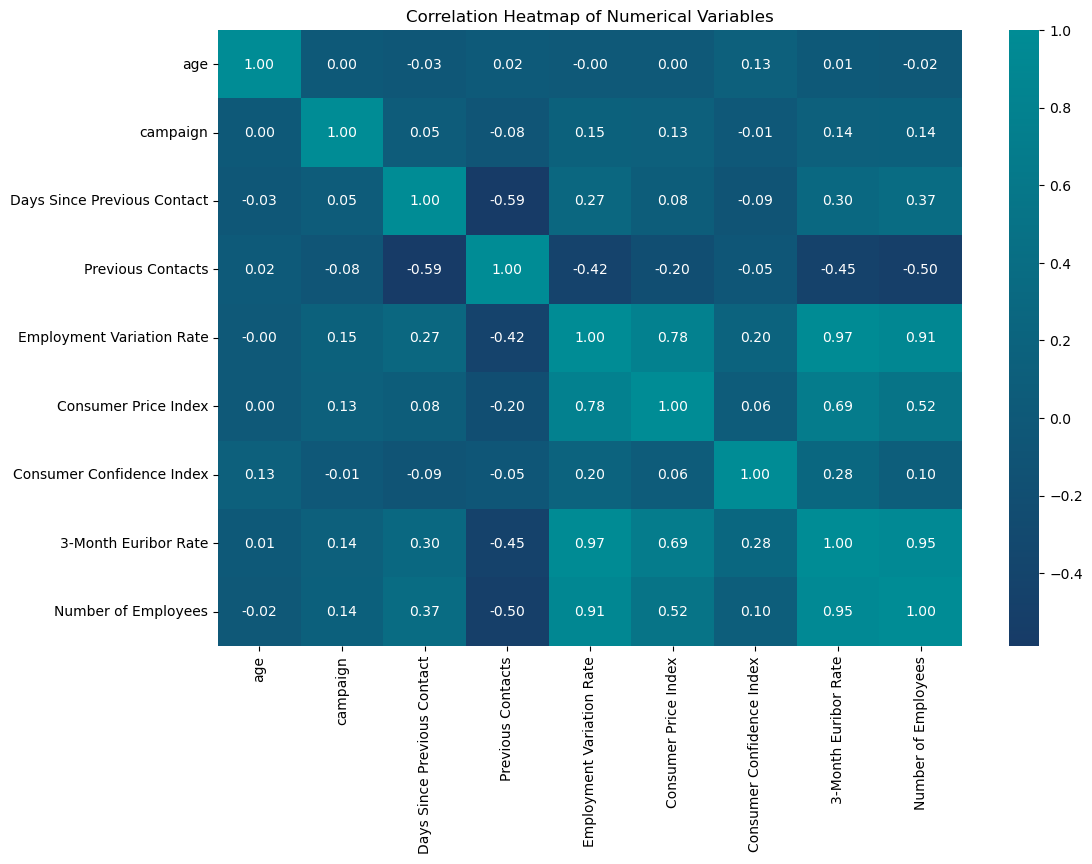

In [14]:
from matplotlib.colors import LinearSegmentedColormap

custom_cmap = LinearSegmentedColormap.from_list(
    "bank_colors",
    ['#173B67', '#008C95']
)

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap=custom_cmap,
    fmt='.2f'
)

plt.title("Correlation Heatmap of Numerical Variables")

plt.show()

     INSIGHT 
* from matplotlib.colors import LinearSegmentedColormap__ Imports a Matplotlib function that allows us to create a custom color gradient.
* #173B67                   __ Navy Blue.
* #008C95                   __ Teal.
* bank_colors               __ name given to the custom color scheme.
* plt.figure(figsize=(12,8))__ Width = 12 ,Height = 8 .
* corr                      __ Uses the correlation matrix calculated earlier.
* annot=True                __ Displays the correlation values inside each cell.
* cmap=custom_cmap          __ Navy Blue and Teal
* fmt='.2f'                 __ Shows correlation values with 2 decimal places.
* plt.title("Correlation Heatmap of Numerical Variables")__Adds a clear title to the chart.
* plt.show()                __ Displays the completed heatmap.
 
 Based on your correlation results :
* Strong positive correlations.
1. Employment Variation Rate    __  3-Month Euribor Rate: 0.97.
2. 3-Month Euribor Rate         __  Number of Employees: 0.95.
3. Employment Variation Rate    __  Number of Employees: 0.91.
4. Employment Variation Rate    __  Consumer Price Index: 0.78.
* Strong negative correlations.
1. Days Since Previous Contact  __  Previous Contacts: -0.59.
2. Previous Contacts            __  Number of Employees: -0.50.
3. Previous Contacts            __ 3-Month Euribor Rate: -0.45.
4. Previous Contacts            __ Employment Variation Rate: -0.42.
* Weak relationships.
1. Age has very weak correlation with most numerical variables.
2. Campaign also has relatively weak correlations with most variables.
 

    2.  Marketing Campaign Analysis
A. Campaign by Month

In [16]:
month_rate = df.groupby('month')['Term Deposit Subscription'].apply(
    lambda x: (x == 'yes').mean() * 100
).sort_values(ascending=False)

print(month_rate)

month
mar    50.549451
dec    48.901099
sep    44.912281
oct    43.871866
apr    20.478723
aug    10.602137
jun    10.511470
nov    10.143867
jul     9.046557
may     6.434745
Name: Term Deposit Subscription, dtype: float64


      INSIGHT
* It helps identify which months had higher or lower subscription rates and understand seasonal patterns in campaign performance.
* df.groupby('month')   __  Group the data by month
* df.groupby('month')['Term Deposit Subscription']__Select the subscription column
* .apply(
    lambda x: (x == 'yes').mean() * 100  __ Apply a calculation to each month
  
* .sort_values(ascending=False)          __ Sort from highest to lowest
* print(month_rate)                      __ Display the result.

     VISUALIZATIONS (Bar Chart)

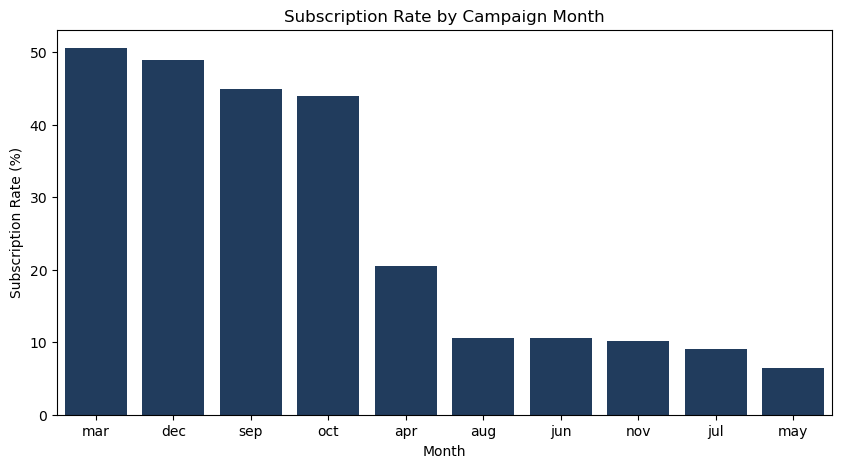

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.barplot(
    x=month_rate.index,
    y=month_rate.values,
    color='#173B67'
)

plt.title("Subscription Rate by Campaign Month")
plt.xlabel("Month")
plt.ylabel("Subscription Rate (%)")

plt.show()


     INSIGHT
* import matplotlib.pyplot as plt  __  Imports Matplotlib for creating and displaying the chart.
* import seaborn as sns            __  Imports Seaborn, which is used here to create the bar chart.
* plt.figure(figsize=(10, 5))      __  Width = 10, Height = 5.
* sns.barplot(                     __  Create the bar chart.
* x=month_rate.index               __  The campaign months are placed on the X-axis.
* y=month_rate.values              __  The subscription rates (%) are placed on the Y-axis.
* color='#173B67'                  __   Navy Blue.
* plt.title("Subscription Rate by Campaign Month")__ Add the title.
* plt.xlabel("Month")              __    Add X-axis label.
* plt.ylabel("Subscription Rate (%)")__  Add Y-axis label.
* plt.show()                       __   Displays the completed chart.
* March had the highest term-deposit subscription rate (50.55%), followed by December (48.90%), while May had the lowest rate (6.43%). The results show substantial variation in subscription rates across campaign months, indicating that campaign performance differs by month in this dataset.


  

    B.  Day of Week Analysis

In [18]:
day_rate = df.groupby('day_of_week')['Term Deposit Subscription'].apply(
    lambda x: (x == 'yes').mean() * 100
)

print(day_rate)

day_of_week
fri    10.808739
mon     9.948320
thu    12.118752
tue    11.779975
wed    11.667076
Name: Term Deposit Subscription, dtype: float64


     INSIGHT
This code calculates the Term Deposit Subscription Rate for each day of the week.
* df.groupby('day_of_week') __ Group customers by day
* df.groupby('day_of_week')['Term Deposit Subscription']__Select the subscription column
* .apply(
    lambda x: (x == 'yes').mean() * 100 __calculates the percentage of customers who subscribed for each day.
* x == 'yes'      __ Checks whether each customer subscribed.
* .mean()         __ Calculate the mean ( True and False ).
*  100            __  subscription rate (%) for each day.
* day_rate        __  percentage of customers subscribed to the term deposit on each campaign day.
* print(day_rate) __  Displays the subscription rate for each day.


In [19]:
day_rate = df.groupby('day_of_week')['Term Deposit Subscription'].apply(
    lambda x: (x == 'yes').mean() * 100
).sort_values(ascending=False)

print(day_rate)

day_of_week
thu    12.118752
tue    11.779975
wed    11.667076
fri    10.808739
mon     9.948320
Name: Term Deposit Subscription, dtype: float64


     INSIGHT
This analysis calculates the percentage of customers who subscribed to a term deposit for each day of the week. It helps identify which days had higher or lower subscription rates.
* df                           __ Bank Direct Marketing dataset.
* .groupby('month')            __ Groups the customers according to the month in which they were contacted.
* ['Term Deposit Subscription']__ After grouping by month, select only the Term Deposit Subscription column.
* .apply(...)                  __ perform a calculation separately for each month.
* lambda x:                    __ lambda creates a small temporary function and x represents the Term Deposit Subscription values for one day.
* (x == 'yes')                 __ Checks whether each customer subscribed.
* .mean()                      __ Calculates the average of True (1) and False (0).
*  100                         __ Converts the decimal into a percentage.
* .sort_values(ascending=False)__ Sorts the results from highest subscription rate to lowest.
* print(day_rate)              __ Displays the final result in the Jupyter Notebook.
* Thursday had the highest subscription rate (12.12%), while Monday had the lowest (9.95%); however, the differences between weekdays were relatively small.

    VISUALIZATIONS (Bar Chart)

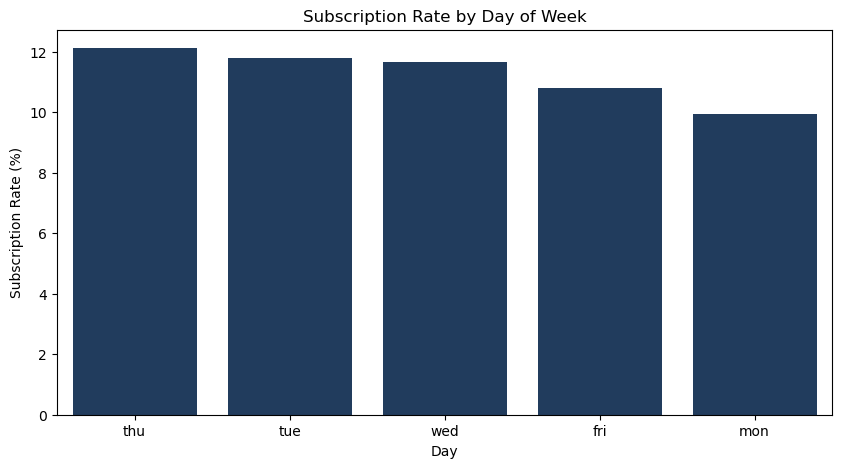

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.barplot(
    x=day_rate.index,
    y=day_rate.values,
    color='#173B67'
)

plt.title("Subscription Rate by Day of Week")
plt.xlabel("Day")
plt.ylabel("Subscription Rate (%)")

plt.show()


      INSIGHT
 The percentage of customers who subscribed on each day of the week.
 * import matplotlib.pyplot as plt __ Imports Matplotlib, which is used to create and customize the chart.
 * import seaborn as sns           __  Imports Seaborn, which is used to create the bar chart.
 * plt.figure(figsize=(10, 5))     __ 10 (width) , 5 (height) .
 * x=day_rate.index                __  puts the days of the week on the X-axis.
* y=day_rate.values                __  puts the subscription rates (%) on the Y-axis.
* color='#173B67'                  __ makes the bars Navy Blue.
* plt.title("Subscription Rate by Day of Week")__Adds the title.
* plt.xlabel("Day")                __ The X-axis represents the day of the week.
* plt.ylabel("SubscriptionRate (%)")__The Y-axis represents the percentage of customers who subscribed to the term deposit.
* plt.show()                       __ Displays the completed chart.
* Thursday shows the highest term-deposit subscription rate (12.12%), while Monday has the lowest (9.95%). However, the rates are relatively close across all weekdays, suggesting that the day of contact has only a modest difference in subscription rates in this dataset.
 



      C. Previous Campaign Outcome

In [22]:
previous_rate = df.groupby('Previous Campaign Result')['Term Deposit Subscription'].apply(
    lambda x: (x == 'yes').mean() * 100
).sort_values(ascending=False)

print(previous_rate)

Previous Campaign Result
success        65.112891
failure        14.228598
nonexistent     8.832213
Name: Term Deposit Subscription, dtype: float64


     INSIGHT
It helps compare subscription rates across different previous campaign outcomes.
* df                    __     Bank Direct Marketing dataset.
* .groupby('Previous Campaign Result') __ customers based on their previous campaign result.
* ['Term Deposit Subscription']        __  we select the Term Deposit Subscription column.
* .apply(                              __  Perform the following calculation separately for each group.
* lambda x:                            __  x represents the subscription values for one group at a time.
* x == 'yes'                           __  This checks which customers subscribed.
* (x == 'yes').mean()                  __  This calculates the proportion of customers who subscribed.
* .mean() * 100                        __  Converts the proportion into a percentage.
* .sort_values(ascending=False)        __  Sorts the subscription rates from highest to lowest.
* previous_rate =                      __  Term Deposit Subscription Rate based on Previous Campaign Result.
* print(previous_rate)                 __   Displays the final result
* Customers with a previous successful campaign result had the highest subscription rate (65.11%), while customers with no previous campaign result had the lowest (8.83%). This shows a strong association between previous campaign outcome and term-deposit subscription in this dataset.
  

    VISUALIZATIONS (Bar Chart)

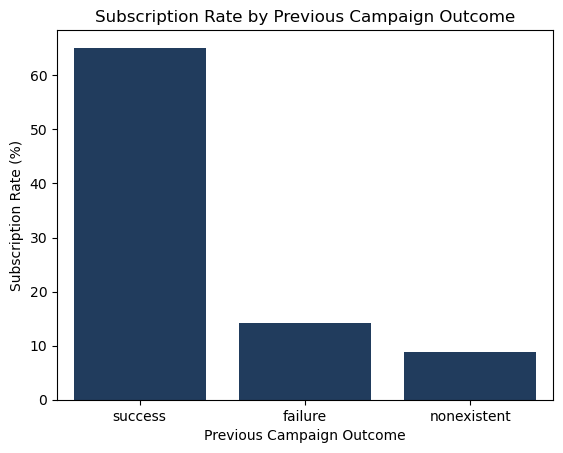

In [33]:
sns.barplot(
    x=previous_rate.index,
    y=previous_rate.values,
    color='#173B67'
)

plt.title("Subscription Rate by Previous Campaign Outcome")
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Subscription Rate (%)")

plt.show()


     INSIGHT
* sns.barplot()          __ creates a bar chart using Seaborn.
* x=previous_rate.index  __ The X-axis gets the category names from previous_rate.index.
* y=previous_rate.values __ The Y-axis gets the subscription-rate values from previous_rate.values.
* color='#173B67'        __  Sets the bars to Navy Blue.
* plt.title("Subscription Rate by Previous Campaign Outcome") __ Add the chart tittle.
* plt.xlabel("Previous Campaign Outcome")__ The X-axis represents the outcome of the previous campaign.
* plt.ylabel("Subscription Rate (%)") __ The Y-axis represents the percentage of customers who subscribed to the term deposit.
* plt.show()             __  displays the completed bar chart.
* Success: Customers with a successful previous campaign result have the highest subscription rate at 65.11%.
* Failure: Customers with a previous failed campaign result have a much lower rate of 14.23%.
* Nonexistent: Customers with no previous campaign outcome have the lowest rate at 8.83%.              * This suggests that previous campaign success is strongly associated with subscription response in this dataset.
 

  

     3. Pie Chart

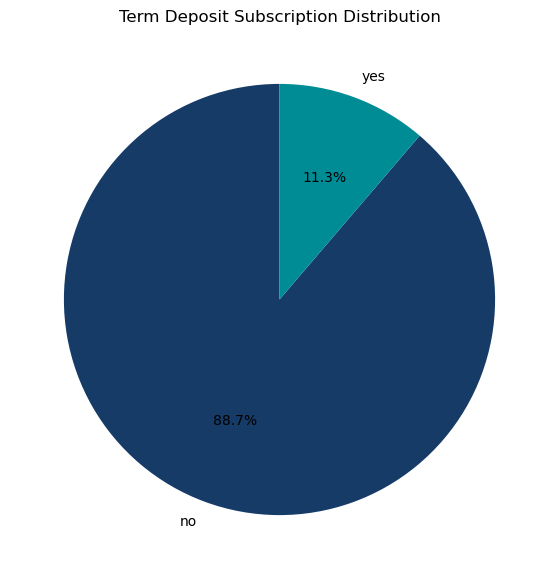

In [23]:
subscription = df['Term Deposit Subscription'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    subscription,
    labels=subscription.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#173B67', '#008C95']
)

plt.title("Term Deposit Subscription Distribution")

plt.show()


     INSIGHT
* value_counts()               __      counts Yes and No subscriptions.
* plt.pie()                    __      creates a pie chart.
* labels=subscription.index    __      shows yes/no labels.
* autopct='%1.1f%%'            __      displays the percentage.
* startangle=90                __      starts the pie chart from the top.
* #008C95                      __      Teal.
*  #173B67                      __      Navy Blue.
* The chart shows the overall distribution of customers who subscribed and did not subscribe.

     4. Scatter Plot

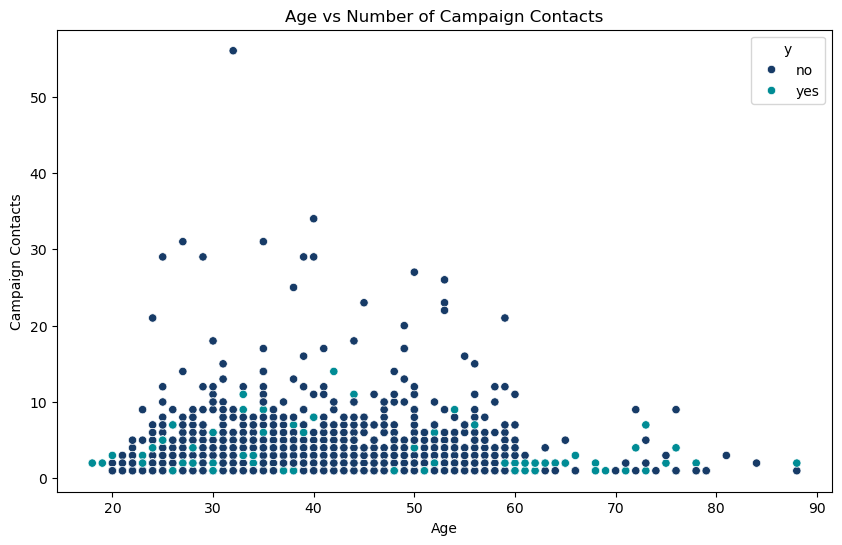

In [35]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df.sample(3000),
    x='age',
    y='campaign',
    hue='Term Deposit Subscription',
    palette={
        'no': '#173B67',
        'yes': '#008C95'
    }
)

plt.title("Age vs Number of Campaign Contacts")
plt.xlabel("Age")
plt.ylabel("Campaign Contacts")

plt.show()

     INSIGHT
* df.sample(3000)                __  randomly selects 3,000 records to make the chart easier to read.
* sns.scatterplot()              __  creates a scatter plot.
* age                            __  shown on the X-axis.
* campaign                       __  shown on the Y-axis, representing the number of campaign contacts.
* hue='Term Deposit Subscription'__  separates the points based on subscription (yes / no).
* #008C95                        __  Teal
* #173B67                        __  Navy Blue
* The graph helps examine the relationship between customer age and the number of campaign contacts.
  

      5. Term Deposit Subscription Rate by Age Group (%)

In [24]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=[
        'Below 25',
        '25-35',
        '36-45',
        '46-55',
        '56-65',
        '65+'
    ]
)


 It helps to create age groups.

In [25]:
age_group_rate = df.groupby(
    'age_group',
    observed=False
)['Term Deposit Subscription'].apply(
    lambda x: (x == 'yes').mean() * 100
)

print(age_group_rate)

age_group
Below 25    20.948379
25-35       11.719539
36-45        8.509810
46-55        8.691963
56-65       15.221060
65+         46.849758
Name: Term Deposit Subscription, dtype: float64


     INSIGHT
Term deposit subscription rates vary significantly by age group. Customers aged 65+ have the highest subscription rate at 46.85%, followed by customers below 25 at 20.95%. The 36–45 age group has the lowest rate at 8.51%, while the 46–55 group is slightly higher at 8.69%.

    VISUALIZATIONS (Bar Chart)

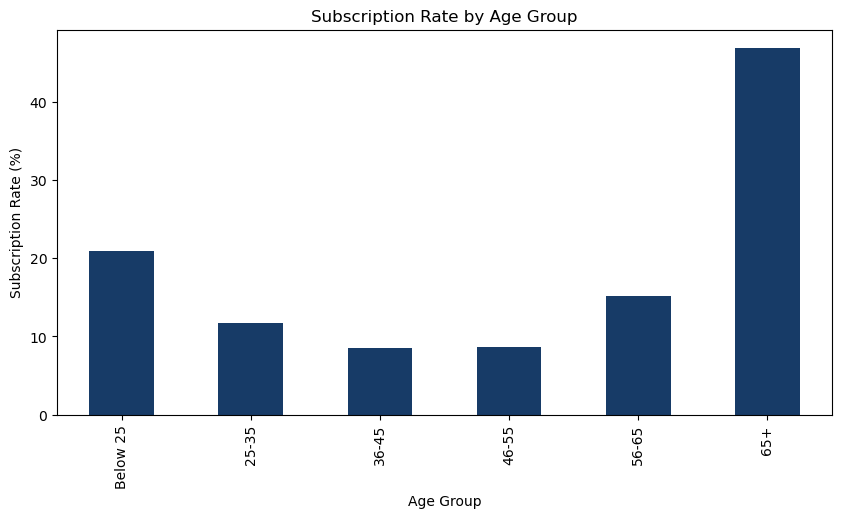

In [26]:
import matplotlib.pyplot as plt

age_group_rate.plot(
    kind='bar',
    figsize=(10, 5),
    color='#173B67'
)

plt.title("Subscription Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Subscription Rate (%)")

plt.show()

     INSIGHT
* import matplotlib.pyplot as plt             __ Imports Matplotlib's pyplot module so we can create and customize the chart.
* kind='bar'                                  __ creates a bar chart.
* figsize=(10, 5)                             __sets the chart size to 10 inches wide × 5 inches high.
* color='#173B67'                             __   gives all bars Navy Blue color.
* plt.title("Subscription Rate by Age Group") __ Adds the chart title.
* plt.xlabel("Age Group")                     __ X-axis contains ( Age Group ).
* plt.ylabel("Subscription Rate (%)")         __ Y-axis shows the subscription rate as a percentage.
* plt.show()                                  __ Displays the completed chart.
*  #173B67                                    __Navy Blue bar.
* Subscription rates vary considerably by age group. Customers aged 65+ show the highest subscription rate (46.85%), while customers aged 36–45 show the lowest (8.51%). The results indicate that age groups respond differently to the term-deposit campaign, with particularly high subscription rates among customers aged 65+.

## PROJECT REPORT 
* The analysis provides several useful insights into customer characteristics and direct marketing campaign performance. Differences in subscription rates across job, education, age group, contact method, campaign month, and previous campaign outcomes can help the bank understand which customer segments responded differently to marketing efforts.

* The analysis of campaign contacts also helps identify patterns in the number of contacts made to customers and their relationship with subscription outcomes. This can support the bank in reviewing contact frequency and identifying whether repeated contacts are associated with different customer responses.

* Campaign timing analysis can reveal variations in customer responses across different months and days of the week. These observed patterns can help the bank evaluate when marketing activities were more successful and support future campaign planning.

* The correlation and statistical analysis also provide a better understanding of relationships among customer, campaign, and economic variables. These findings can be used as supporting information when developing predictive models and evaluating factors associated with term-deposit subscriptions.

* The findings can help the bank improve customer segmentation, refine targeting strategies, evaluate contact approaches, plan campaign timing, monitor marketing performance, and make better data-driven decisions. The findings represent observed patterns in the dataset and should be further validated through future campaigns or predictive modeling before being used as definitive business rules.


## RECOMMENDATIONS
1. Improve Customer Targeting :
Segment customers based on observed subscription rates, demographics, job, education, and previous  campaign outcomes.
2. Optimize Contact Strategy :
Compare different contact methods and contact frequencies to understand which approaches are associated with better responses.
3. Study Campaign Timing : 
Analyze subscription rates by month and day of the week to identify useful patterns for future campaign planning.
4. Monitor Campaign Performance :
Regularly track subscription rate, number of contacts, and segment-level performance through dashboards or reports.
5. Use Previous Campaign Results :
Examine previous campaign outcomes when evaluating customer responses and planning future marketing activities.
6. Analyze Customer Age Groups :
Compare subscription patterns across different age groups to understand how customer responses vary across the dataset.
7. Evaluate Job and Education Segments :
Study subscription rates across job and education categories to identify differences in campaign response.
8. Review Contact Frequency :
Analyze whether repeated contacts are associated with different subscription outcomes and use controlled testing before changing contact policies.
9. Use Data-Driven Campaign Testing :
 Conduct A/B or controlled experiments for contact methods, timing, and messaging rather than relying only on historical patterns.
10. Develop Predictive Models :
Use machine-learning techniques to estimate the likelihood of term-deposit subscription and compare model performance using appropriate evaluation metrics.
11. Monitor Economic Factors :
 Consider the observed relationships among economic variables such as employment variation, Euribor rate, consumer price index, and number of employees when interpreting campaign results.
12. Responsible Marketing :
Respect customer privacy, consent, and contact preferences. Customer characteristics should not be used for unfair or unsupported decisions.



##  CONCLUSION 
* This project demonstrates how Python-based data analytics can be effectively used to analyze and understand Bank Direct Marketing Campaigns. The analysis followed a structured process involving data collection, data preprocessing, data cleaning, exploratory data analysis, statistical analysis, correlation analysis, pivot-table analysis, and data visualization.
* The dataset contains 41,188 customer records and 20 variables, covering customer demographics, campaign-related information, previous campaign outcomes, and economic indicators. Through the analysis, different customer characteristics and campaign variables were examined to understand their observed relationship with Term Deposit Subscription.
* The exploratory analysis provided insights into customer distribution across age, job, marital status, education, contact method, campaign month, and previous campaign outcomes. Statistical analysis helped summarize important numerical characteristics such as customer age, while correlation analysis helped identify relationships among the numerical variables. Pivot tables and group-based analysis provided additional comparisons between customer segments and subscription outcomes.

       Main Result :

* The dataset contains 41,188 records, with an observed term-deposit subscription rate of approximately 11.27%. The analysis indicates that subscription outcomes vary across different customer segments and campaign characteristics. These observed differences can help the bank understand customer response patterns and identify areas that may require further investigation.

* The project also highlights the importance of campaign contact frequency and timing. Examining the number of contacts, contact methods, campaign months, and previous campaign results can provide useful information for evaluating marketing strategies. However, these relationships are observational and do not establish causation.

* The insights generated from this project can support customer segmentation, campaign planning, performance monitoring, and future predictive modeling. A machine-learning model could be developed in a future stage to predict the likelihood of a customer subscribing to a term deposit and to evaluate model performance using appropriate metrics.

* Overall, this project demonstrates how data analytics can transform a large banking dataset into meaningful insights for data-driven decision-making. The findings can serve as a foundation for further analysis and controlled experimentation. Before implementing major business changes, the observed patterns should be validated using future campaign data, controlled testing, and appropriate business evaluation.

## Business Problem : Improving Direct Marketing Campaign Effectiveness.
The bank aims to improve the effectiveness of its direct marketing campaigns by understanding customer characteristics and campaign factors associated with term-deposit subscriptions.
The key business problems addressed in this project are:
1. Understand Customer Characteristics :
Analyze customer demographics such as age, job, marital status, and education to understand  differences in campaign responses.
2. Identify Customer Segments :
Examine different customer groups and their observed term-deposit subscription rates to support more focused campaign analysis.
3. Analyze Campaign Contact Patterns : 
Study the number and frequency of contacts made to customers and examine their association with subscription outcomes.
4. Evaluate Contact Methods :
Compare different communication methods and their observed subscription rates to understand customer response patterns.
5. Analyze Campaign Timing :
Examine subscription patterns across different months and days of the week to identify useful timing patterns.
6. Study Previous Campaign Outcomes :
Analyze previous campaign results and their relationship with the current campaign response.
7. Understand Economic Factors
Examine economic indicators such as employment variation rate, consumer price index, consumer confidence index, Euribor rate, and number of employees.
Measure Campaign Performance :
8. Calculate the overall subscription rate and compare performance across different customer and campaign segments.
9. Discover Relationships Between Variables:
Use correlation analysis, statistical analysis, groupby operations, and pivot tables to identify relationships and patterns within the dataset.
10. Support Data-Driven Decision-Making :
Convert the analytical findings into practical insights that can support customer targeting, campaign planning, and marketing performance monitoring.
11. Reduce Inefficient Campaign Efforts :
Analyze contact patterns and customer responses to help the bank evaluate whether campaign resources are being used effectively.
12. Provide a Foundation for Prediction :
Use the insights from exploratory analysis as a foundation for future machine-learning models that can predict the likelihood of term-deposit subscription.
13. Improve Marketing Evaluation : 
Establish measurable indicators such as subscription rate, customer segment response, contact frequency, and campaign timing for ongoing performance evaluation.
14. Validate Findings Through Testing :
Since the analysis is observational, the identified relationships should be validated through future campaigns and controlled experiments before major business decisions are made.

    Overall Business Objective :
The overall objective is to use customer, campaign, and economic data to better understand what patterns are associated with term-deposit subscriptions, helping the bank evaluate its marketing activities and develop more data-driven and responsible campaign strategies.

